# Test de différentes interpolations

In [89]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d, make_lsq_spline, BSpline
import matplotlib.pyplot as plt


df = pd.read_csv("../data/data_02923X0007_F.csv", sep=";")

df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

valeur_de_travail = 'niveau_nappe_eau'

df[valeur_de_travail] = pd.to_numeric(df[valeur_de_travail], errors='coerce')

x = np.arange(len(df))
y = df[valeur_de_travail].values

## Interpolation linéaire

Remarques : Déjà utilisé par Ethienne.

In [90]:
df['niveau_interp_linear'] = df[valeur_de_travail].interpolate(method='linear', limit_direction='both')

## Interpolation via spline cubique

Remarques : Formes interescente, à creser. 
Mauvais pour : l'ETP_Q

In [91]:
mask = ~np.isnan(y)

f_cubic = interp1d(x[mask], y[mask], kind='cubic', fill_value="extrapolate")
df['niveau_interp_cubic'] = f_cubic(x)

## Interpolation via Polynômes de degré n

Remarques :
C'est pas très bon et en soit je pense qu'une ia marchera bien mieux pour combler les données qui manque

In [92]:
mask = ~np.isnan(y)
x_known = x[mask]
y_known = y[mask]

n_degree = 40
coeffs = np.polyfit(x_known, y_known, deg=n_degree)

poly_func = np.poly1d(coeffs)

df['niveau_poly'] = poly_func(x)

c:\Users\tronn\Documents\STAGE-Junon\venv\Lib\site-packages\numpy\lib\_polynomial_impl.py:673: RuntimeWarning: overflow encountered in multiply
  scale = NX.sqrt((lhs * lhs).sum(axis=0))
c:\Users\tronn\Documents\STAGE-Junon\venv\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\tronn\AppData\Local\Temp\ipykernel_4208\2366644834.py:6: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_known, y_known, deg=n_degree)


## Interpolation via B-spline

In [93]:
import numpy as np
from scipy.interpolate import make_lsq_spline


mask = ~np.isnan(y)
x_known = x[mask]
y_known = y[mask]

sort_idx = np.argsort(x_known)
x_sorted = x_known[sort_idx]
y_sorted = y_known[sort_idx]

k = 100 
n_internal_knots = 6

knots_internal = np.linspace(x_sorted.min(), x_sorted.max(), n_internal_knots + 2)[1:-1]


t = np.concatenate([
    np.full(k + 1, x_sorted.min()), 
    knots_internal, 
    np.full(k + 1, x_sorted.max())
])

spl = make_lsq_spline(x_sorted, y_sorted, t, k)
y_spline = spl(x)

df['niveau_spline_b'] = y_spline

In [94]:
df['niveau_pchip'] = df[valeur_de_travail].interpolate(method='pchip')

## Resultat

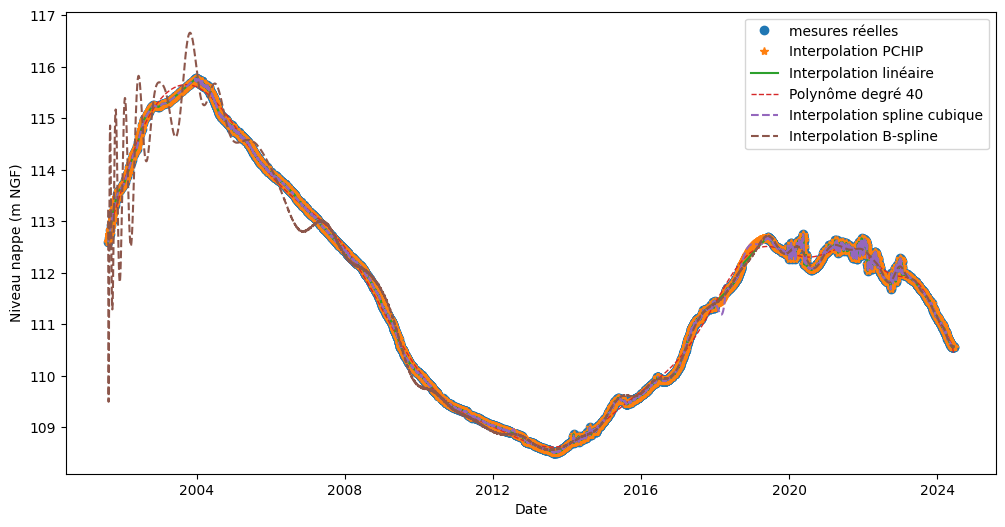

In [99]:
plt.figure(figsize=(12,6))
plt.plot(df[valeur_de_travail], 'o', label='mesures réelles')
plt.plot(df['niveau_pchip'], '*', label='Interpolation PCHIP')
plt.plot(df['niveau_interp_linear'], '-', label='Interpolation linéaire')
plt.plot(df['niveau_poly'], '--', label=f'Polynôme degré {n_degree}', linewidth=1)
plt.plot(df['niveau_interp_cubic'], '--', label='Interpolation spline cubique')
plt.plot(df['niveau_spline_b'], '--', label='Interpolation B-spline')

plt.xlabel("Date")
plt.ylabel("Niveau nappe (m NGF)")
plt.legend()
plt.show()